In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    features = {}
    
    # Color features (9 features)
    for i, color in enumerate(['blue', 'green', 'red']):
        channel = img[:,:,i]
        features[f'{color}_mean'] = np.mean(channel)
        features[f'{color}_std'] = np.std(channel)
        features[f'{color}_median'] = np.median(channel)
    
    return features

In [3]:
# 2. Process all images
def process_dataset(root_dir):
    classes = ['Normal_Sperm', 'Abnormal_Sperm', 'Non-Sperm']
    features = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            continue
            
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.bmp')):
                img_path = os.path.join(class_dir, img_file)
                try:
                    feats = extract_features(img_path)
                    features.append(feats)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
    
    features_df = pd.DataFrame(features)
    labels_df = pd.DataFrame(labels, columns=["Labels"])
    
    return features_df, labels_df

In [4]:
# 3. Load and prepare data
print("Processing dataset...")
X, y = process_dataset('data')
print(f"Loaded {len(X)} samples with {len(X.columns)} features")


Processing dataset...
Loaded 3000 samples with 9 features


In [5]:
 X.head()

,blue_mean,blue_std,blue_median,green_mean,green_std,green_median,red_mean,red_std,red_median
0,187.631750,6.727344,189.0,195.482972,26.322301,201.0,203.229599,20.622763,208.0
1,180.387137,7.402112,183.0,178.122006,26.331607,188.0,192.168072,21.332094,200.0
2,182.527234,6.709947,184.0,189.309751,27.792789,196.0,199.673465,19.287981,204.0
3,181.531369,6.707462,183.0,184.524464,30.661717,194.0,191.956058,24.780963,198.0
4,181.375974,7.435262,183.0,183.766488,29.446765,192.0,191.745593,26.744912,199.0


In [6]:
y.sample(n=9)

,Labels
1829,1
2742,2
1597,1
694,0
1233,1
1596,1
2168,2
2949,2
560,0


In [7]:
def plot_distribution_before_after(X_before, X_after, feature_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Before scaling
    axes[0].hist(X_before[feature_name], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Before Scaling: {feature_name}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')

    # After scaling
    axes[1].hist(X_after[feature_name], bins=30, color='salmon', edgecolor='black')
    axes[1].set_title(f'After Scaling: {feature_name}')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

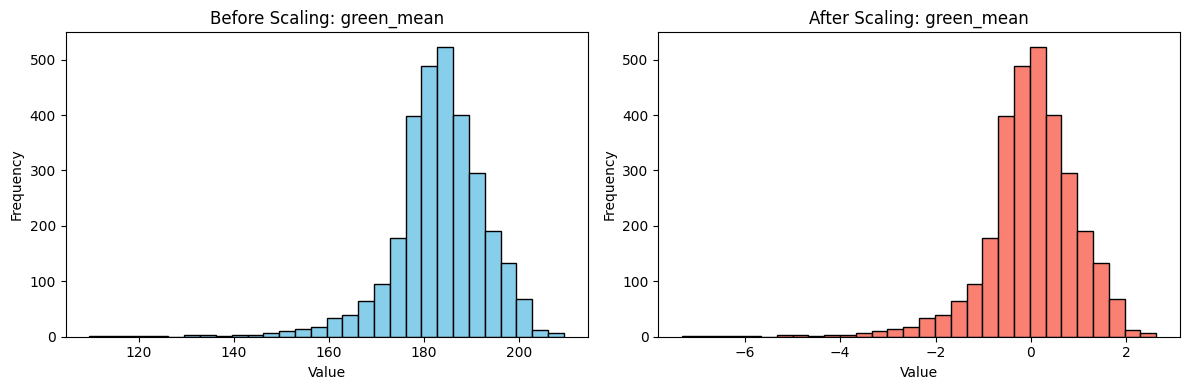

In [8]:
X.columns = X.columns.astype(str)

X_numeric = X.select_dtypes(include=['number'])

# Scale the numeric features
scaler = StandardScaler()
X_after_array = scaler.fit_transform(X_numeric)

# Convert scaled data back to DataFrame
X_after = pd.DataFrame(X_after_array, columns=X_numeric.columns)

feature_name = X_numeric.columns[3]  # or any index
plot_distribution_before_after(X_numeric, X_after, feature_name)

In [9]:
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

X_train, X_test, y_train, y_test = train_test_split(X, y.values.ravel(), test_size=0.2, stratify=y, random_state=42)


In [10]:
# 5. Base Classifier (KNN)
print("\n=== Base Classifier (KNN) ===")
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) ===
              precision    recall  f1-score   support

      Normal       0.51      0.62      0.56       204
    Abnormal       0.54      0.55      0.54       201
   Non-Sperm       0.85      0.65      0.74       195

    accuracy                           0.60       600
   macro avg       0.63      0.61      0.61       600
weighted avg       0.63      0.60      0.61       600



In [11]:
# 6. Advanced Classifiers with Hyperparameter Tuning

## Random Forest
print("\n=== Random Forest (Optimized) ===")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Best params: {rf.best_params_}")
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))



=== Random Forest (Optimized) ===
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.59      0.58      0.58       204
           1       0.56      0.59      0.58       201
           2       0.76      0.74      0.75       195

    accuracy                           0.63       600
   macro avg       0.64      0.63      0.64       600
weighted avg       0.64      0.63      0.63       600



Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.61      0.59      0.60       204
           1       0.60      0.61      0.61       201
           2       0.74      0.74      0.74       195

    accuracy                           0.65       600
   macro avg       0.65      0.65      0.65       600
weighted avg       0.65      0.65      0.65       600



In [12]:
## SVM
print("\n=== SVM (Optimized) ===")
svm_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear']
}
svm = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm.fit(X_train, y_train)
print(f"Best params: {svm.best_params_}")
y_pred_svm = svm.predict(X_test)
print(classification_report(y_test, y_pred_svm))


=== SVM (Optimized) ===
Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.54      0.49      0.51       204
           1       0.52      0.59      0.55       201
           2       0.79      0.76      0.78       195

    accuracy                           0.61       600
   macro avg       0.62      0.61      0.61       600
weighted avg       0.61      0.61      0.61       600



In [13]:
# 7. Visualization
def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal', 'Non-Sperm'],
                yticklabels=['Normal', 'Abnormal', 'Non-Sperm'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


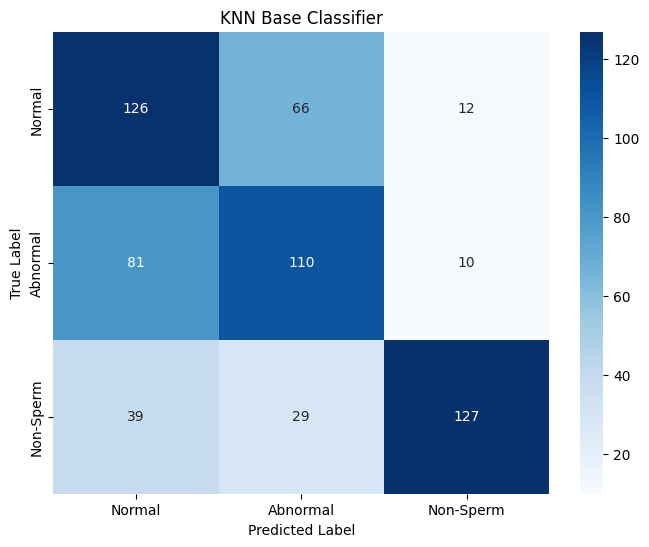

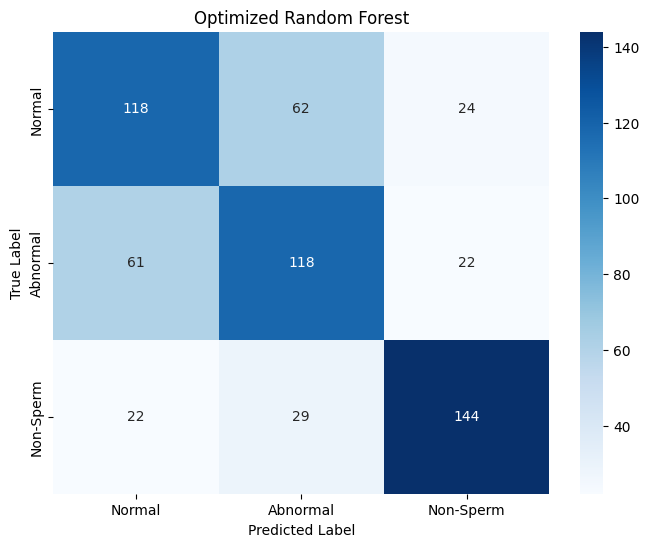

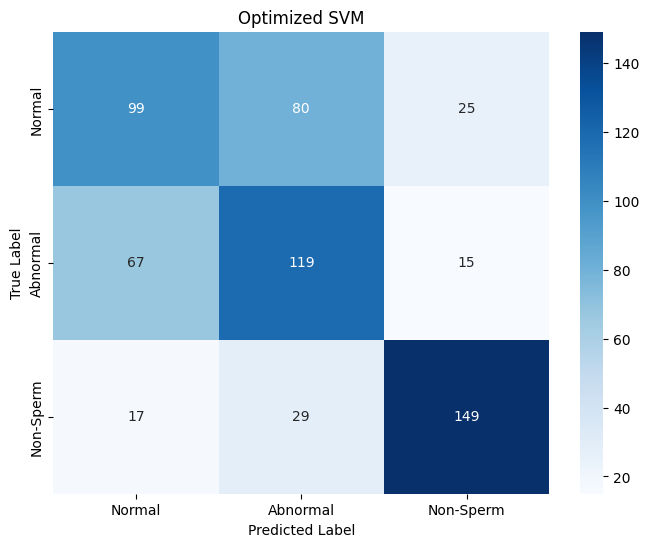

In [14]:
plot_results(y_test, y_pred, "KNN Base Classifier")
plot_results(y_test, y_pred_rf, "Optimized Random Forest")
plot_results(y_test, y_pred_svm, "Optimized SVM")

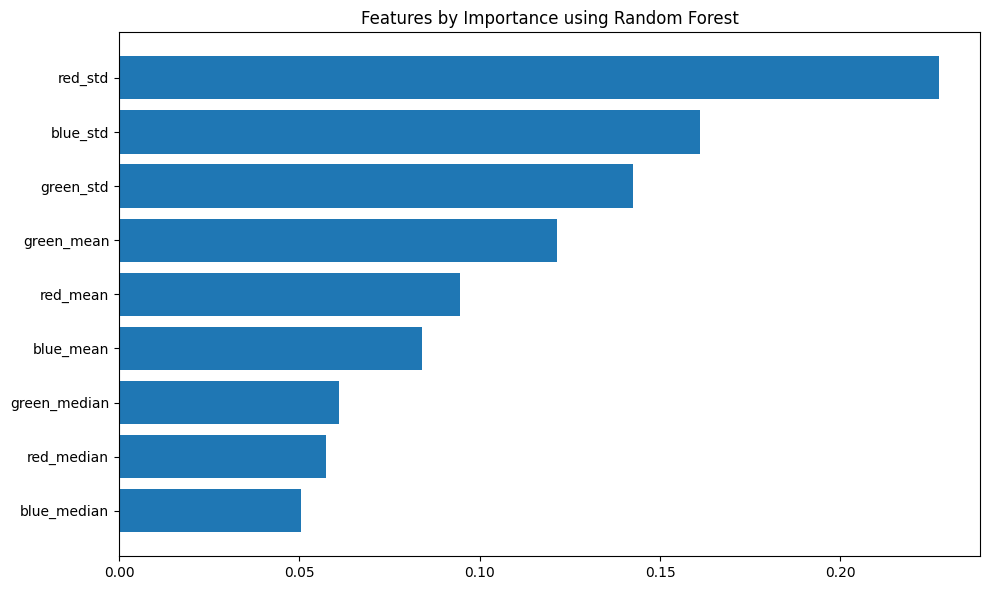

In [15]:
# 8. Feature Importance Analysis
plt.figure(figsize=(10, 6))
importances = rf.best_estimator_.feature_importances_
sorted_idx = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title("Features by Importance using Random Forest")
plt.tight_layout()
plt.show()